# CVXPY para Otimização Convexa e Portfólios

Objetivos:
- Entender a ideia básica de modelagem em CVXPY
- Resolver least squares
- Formular Markowitz / mean-variance
- Adicionar restrições de portfólio
- Ver uma aplicação em matriz de correlação mais próxima

In [22]:
# ! pip install numpy
# ! pip install pandas
# ! pip install cvxpy
# ! pip install matplotlib

In [5]:
import numpy as np
import pandas as pd
import cvxpy as cp
import matplotlib.pyplot as plt

np.random.seed(42)


In [67]:
""" Estrutura do CVXPY """



' Estrutura do CVXPY '

In [53]:
""" Mínimos Quadrados Ordinários"""
# Coletas de dados meteorológicos
days, cities = 30, 5
umidity = 100*np.random.rand(days, cities)
x_true = np.array([1.5, 2.0, 0.5, 0.0, 3.0])
prec_vol = umidity @ x_true + 0.2 * np.random.randn(days)
prec_vol = np.where(prec_vol < 0, 0, prec_vol)


x = cp.Variable(cities) # Variável de decisão
cost = cp.sum_squares(umidity @ x - prec_vol) # Custo
objective = cp.Minimize(cost) # Objetivo
problem = cp.Problem(objective) # Problema, é definido com base no objetivo e restrições
problem.solve()

print("status:", problem.status)
print("x estimado:", x.value)
print("x verdadeiro:", x_true)
print("erro norm:", np.linalg.norm(x.value - x_true))

residual = umidity @ x.value - prec_vol
print("norma do residual:", np.linalg.norm(residual))
print("primeiros 5 resíduos:", residual[:5])

status: optimal
x estimado: [ 1.49826983e+00  2.00092509e+00  5.01962559e-01 -3.00688741e-04
  2.99891492e+00]
x verdadeiro: [1.5 2.  0.5 0.  3. ]
erro norm: 0.002994784807640102
norma do residual: 1.1339571758284037
primeiros 5 resíduos: [ 0.39029364 -0.14077692  0.13773697  0.00056314  0.15348102]


In [54]:
""" Dados sintéticos """

n_assets = 6
assets = [f"A{i+1}" for i in range(n_assets)]

mu = np.array([0.12, 0.10, 0.14, 0.08, 0.11, 0.09]) # Retornos estimados
X = np.random.randn(n_assets, n_assets)
Sigma = X.T @ X / 10 + 0.02 * np.eye(n_assets) # Variância estimada

rf = 0.03 # Taxa livre de risco

print("retornos esperados:", mu)
print("matriz de covariância:\n", Sigma)

retornos esperados: [0.12 0.1  0.14 0.08 0.11 0.09]
matriz de covariância:
 [[ 0.55977251 -0.23938875  0.15268321 -0.02796111  0.18953891 -0.0080121 ]
 [-0.23938875  0.88755705 -0.11395488  0.0930351  -0.13380786  0.05141938]
 [ 0.15268321 -0.11395488  0.60721147  0.01026432 -0.08625822  0.01827503]
 [-0.02796111  0.0930351   0.01026432  0.05736492 -0.06391708  0.06739128]
 [ 0.18953891 -0.13380786 -0.08625822 -0.06391708  0.59958003 -0.13246058]
 [-0.0080121   0.05141938  0.01827503  0.06739128 -0.13246058  0.21202675]]


In [56]:
""" Métodos para visualização"""

def portfolio_stats(w, mu, Sigma, rf=0.03):
    ret = float(mu @ w)
    vol = float(np.sqrt(w.T @ Sigma @ w))
    sharpe = (ret - rf) / vol if vol > 0 else np.nan
    return ret, vol, sharpe

def show_weights(w, title="Pesos"):
    df = pd.DataFrame({"asset": assets, "weight": np.round(w, 4)})
    print(title)
    display(df)

In [57]:
""" Carteira de mínima variância"""

w = cp.Variable(n_assets)
objective = cp.Minimize(cp.quad_form(w, Sigma))
constraints = [cp.sum(w) == 1, w >= 0]
prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.OSQP)

w_minvar = w.value
show_weights(w_minvar, "Carteira de mínima variância")

ret, vol, sharpe = portfolio_stats(w_minvar, mu, Sigma, rf)
print("retorno:", ret)
print("volatilidade:", vol)
print("Sharpe:", sharpe)

Carteira de mínima variância


,asset,weight
0,A1,0.0402
1,A2,-0.0000
2,A3,0.0537
3,A4,0.7678
4,A5,0.1357
5,A6,0.0026


retorno: 0.08892905907698886
volatilidade: 0.18699159192788853
Sharpe: 0.3151428279177081


In [58]:
""" Retorno alvo """

target_return = 0.11

w = cp.Variable(n_assets)
objective = cp.Minimize(cp.quad_form(w, Sigma))
constraints = [
    cp.sum(w) == 1,
    w >= 0,
    mu @ w >= target_return
]
prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.OSQP)

w_mv = w.value
show_weights(w_mv, "Mean-variance com retorno alvo")

ret, vol, sharpe = portfolio_stats(w_mv, mu, Sigma, rf)
print("retorno:", ret)
print("volatilidade:", vol)
print("Sharpe:", sharpe)

Mean-variance com retorno alvo


,asset,weight
0,A1,0.0900
1,A2,0.1316
2,A3,0.2438
3,A4,0.0667
4,A5,0.2231
5,A6,0.2449


retorno: 0.10999999999999999
volatilidade: 0.2747521494326037
Sharpe: 0.29117151645659417


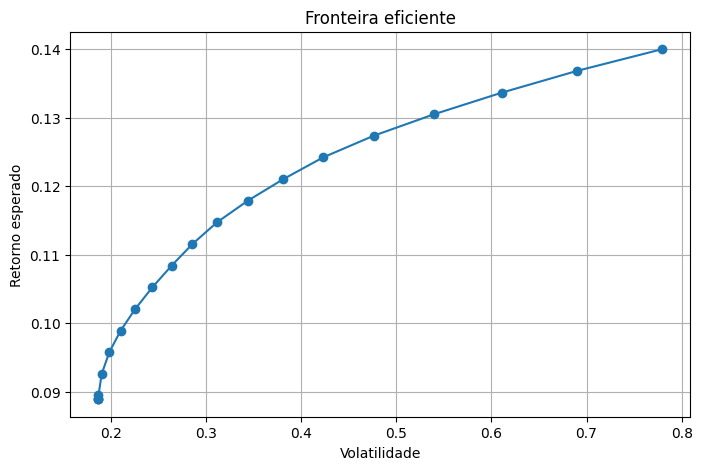

In [59]:
""" Fronteira eficiente """

targets = np.linspace(mu.min(), mu.max(), 20)
rets, vols = [], []
weights = []

for t in targets:
    w = cp.Variable(n_assets)
    objective = cp.Minimize(cp.quad_form(w, Sigma))
    constraints = [cp.sum(w) == 1, w >= 0, mu @ w >= t]
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.OSQP)
    
    if w.value is not None:
        weights.append(w.value)
        r, v, _ = portfolio_stats(w.value, mu, Sigma, rf)
        rets.append(r)
        vols.append(v)

plt.figure(figsize=(8, 5))
plt.plot(vols, rets, marker="o")
plt.xlabel("Volatilidade")
plt.ylabel("Retorno esperado")
plt.title("Fronteira eficiente")
plt.grid(True)
plt.show()

In [60]:
""" Máximo Sharpe """

w = cp.Variable(n_assets)
excess_return = mu - rf

objective = cp.Maximize(excess_return @ w)
constraints = [
    cp.quad_form(w, Sigma) <= 1,
    cp.sum(w) == 1,
    w >= 0
]
prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.SCS)

w_sharpe = w.value
show_weights(w_sharpe, "Carteira de máximo Sharpe")

ret, vol, sharpe = portfolio_stats(w_sharpe, mu, Sigma, rf)
print("retorno:", ret)
print("volatilidade:", vol)
print("Sharpe:", sharpe)

Carteira de máximo Sharpe


,asset,weight
0,A1,0.0
1,A2,-0.0
2,A3,1.0
3,A4,-0.0
4,A5,0.0
5,A6,-0.0


retorno: 0.140000005075656
volatilidade: 0.7792378009222319
Sharpe: 0.14116358953001307


In [61]:
""" Adicionando restrições ao portfólio """

w = cp.Variable(n_assets)

constraints = [
    cp.sum(w) == 1,
    w >= 0,
    w <= 0.35
]

# Exemplo: limite de 50% em um subconjunto de ativos
constraints.append(cp.sum(w[[0, 2, 4]]) <= 0.50)

objective = cp.Minimize(cp.quad_form(w, Sigma) - 1.5 * mu @ w)
prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.OSQP)

w_constrained = w.value
show_weights(w_constrained, "Carteira com restrições")

ret, vol, sharpe = portfolio_stats(w_constrained, mu, Sigma, rf)
print("retorno:", ret)
print("volatilidade:", vol)
print("Sharpe:", sharpe)

Carteira com restrições


,asset,weight
0,A1,0.0635
1,A2,0.0734
2,A3,0.1448
3,A4,0.3500
4,A5,0.1895
5,A6,0.1788


retorno: 0.10017117191488607
volatilidade: 0.21688969317802026
Sharpe: 0.32353391664992803


In [15]:
benchmark = np.array([0.20, 0.15, 0.15, 0.15, 0.20, 0.15])

w = cp.Variable(n_assets)
active = w - benchmark

objective = cp.Maximize((mu - mu @ benchmark) @ w)
constraints = [
    cp.sum(w) == 1,
    w >= 0,
    cp.quad_form(active, Sigma) <= 0.02
]
prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.SCS)

w_active = w.value
show_weights(w_active, "Carteira ativa")

print("active weights:", np.round(w_active - benchmark, 4))

Carteira ativa


,asset,weight
0,A1,0.2754
1,A2,-0.0000
2,A3,0.4835
3,A4,-0.0000
4,A5,0.1494
5,A6,0.0917


active weights: [ 0.0754 -0.15    0.3335 -0.15   -0.0506 -0.0583]


,strategy,return,vol,sharpe
0,min_var,0.088929,0.186992,0.315143
1,mean_variance,0.110000,0.274752,0.291172
2,max_sharpe,0.140000,0.779238,0.141164
3,constrained,0.100171,0.216890,0.323534
4,active,0.125426,0.490887,0.194395


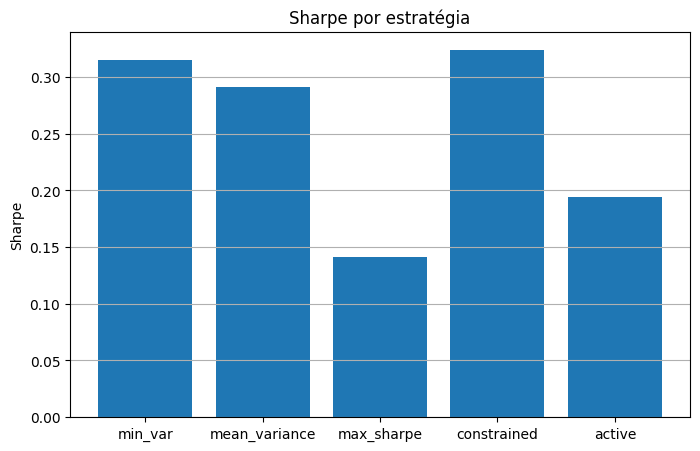

In [63]:
""" Comparando carteiras """

results = pd.DataFrame([
    ["min_var", *portfolio_stats(w_minvar, mu, Sigma, rf)],
    ["mean_variance", *portfolio_stats(w_mv, mu, Sigma, rf)],
    ["max_sharpe", *portfolio_stats(w_sharpe, mu, Sigma, rf)],
    ["constrained", *portfolio_stats(w_constrained, mu, Sigma, rf)],
    ["active", *portfolio_stats(w_active, mu, Sigma, rf)],
], columns=["strategy", "return", "vol", "sharpe"])

display(results)

plt.figure(figsize=(8, 5))
plt.bar(results["strategy"], results["sharpe"])
plt.ylabel("Sharpe")
plt.title("Sharpe por estratégia")
plt.grid(axis="y")
plt.show()

In [64]:
""" Carteira com shrinkage """

alpha = 0.30
F = np.diag(np.diag(Sigma))
Sigma_shrink = (1 - alpha) * Sigma + alpha * F

w = cp.Variable(n_assets)
objective = cp.Minimize(cp.quad_form(w, Sigma_shrink) - 1.2 * mu @ w)
constraints = [cp.sum(w) == 1, w >= 0]
prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.OSQP)

w_shrink = w.value
show_weights(w_shrink, "Carteira com shrinkage")

Carteira com shrinkage


,asset,weight
0,A1,0.0779
1,A2,0.0447
2,A3,0.1080
3,A4,0.5246
4,A5,0.1382
5,A6,0.1067


matriz original:
 [[ 1.   1.2  0.3]
 [ 1.2  1.  -0.4]
 [ 0.3 -0.4  1. ]]

matriz corrigida:
 [[ 1.      0.9034  0.1709]
 [ 0.9034  1.     -0.268 ]
 [ 0.1709 -0.268   1.    ]]

autovalores corrigidos: [-2.05247849e-06  1.09107402e+00  1.90892803e+00]


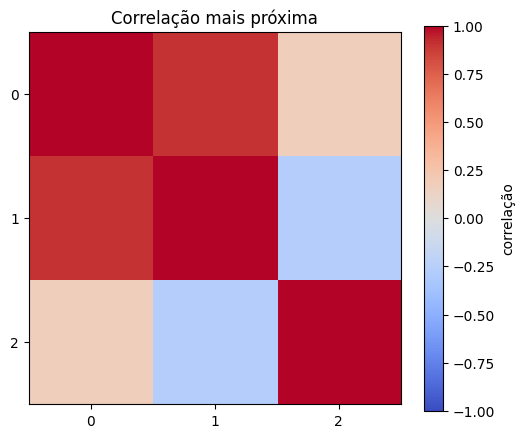

In [65]:
R = np.array([
    [1.0,  1.2,  0.3],
    [1.2,  1.0, -0.4],
    [0.3, -0.4,  1.0]
])

# Simetrização leve
R = (R + R.T) / 2

X = cp.Variable((3, 3), symmetric=True)
objective = cp.Minimize(cp.norm(X - R, "fro"))
constraints = [
    cp.diag(X) == 1,
    X >> 0
]
prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.SCS)

R_near = X.value
print("matriz original:\n", R)
print("\nmatriz corrigida:\n", np.round(R_near, 4))
print("\nautovalores corrigidos:", np.linalg.eigvalsh(R_near))

plt.figure(figsize=(6, 5))
plt.imshow(R_near, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="correlação")
plt.title("Correlação mais próxima")
plt.xticks(range(3))
plt.yticks(range(3))
plt.show()

In [66]:
""" Função geral para o problema de Markowitz """

def solve_markowitz(mu, Sigma, target=None, long_only=True):
    n = len(mu)
    w = cp.Variable(n)
    constraints = [cp.sum(w) == 1]
    if long_only:
        constraints.append(w >= 0)
    if target is not None:
        constraints.append(mu @ w >= target)
    objective = cp.Minimize(cp.quad_form(w, Sigma))
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.OSQP)
    return w.value, prob.status

## Exercício

1. Troque os retornos esperados por dados reais.
2. Coloque restrição de setor.
3. Monte a fronteira eficiente.
4. Compare covariância amostral vs. shrinkage.
5. Altere o benchmark e refaça a carteira ativa.